## Linear Interpolation for Handling Missing Values

In [5]:
import pandas as pd

import matplotlib.pyplot as plt

In [1]:
# (SKIP)
# import pandas as pd
# import numpy as np

# # Create date range from Jan 1 to Jan 30
# dates = pd.date_range(start="2026-01-01", end="2026-01-30")

# # Create a base linear trend from 20 to 50
# base_temp = np.linspace(20, 50, len(dates))

# # Add small random noise so it is not perfectly linear
# np.random.seed(42)  # for reproducibility
# noise = np.random.normal(0, 1.5, len(dates))

# temperature = base_temp + noise

# # Create DataFrame
# df = pd.DataFrame({
#     "date": dates.strftime("%Y-%m-%d"),
#     "temperature": temperature.round(2)
# })

# # Save to CSV
# df.to_csv("missing_hourly_temperature_linear2.csv", index=False)

# print("CSV file 'temperature_january.csv' created successfully")


CSV file 'temperature_january.csv' created successfully


In [8]:
# 1) read csv
df = pd.read_csv('missing_hourly_temperature_linear.csv')
print(df)

          date  temperature
0   2026-01-01        20.75
1   2026-01-02        20.83
2   2026-01-03        23.04
3   2026-01-04          NaN
4   2026-01-05          NaN
5   2026-01-06        24.82
6   2026-01-07        28.58
7   2026-01-08        28.39
8   2026-01-09        27.57
9   2026-01-10        30.12
10  2026-01-11        29.65
11  2026-01-12          NaN
12  2026-01-13        32.78
13  2026-01-14        30.58
14  2026-01-15        31.90
15  2026-01-16        34.67
16  2026-01-17        35.03
17  2026-01-18        38.06
18  2026-01-19        37.26
19  2026-01-20          NaN
20  2026-01-21        42.89
21  2026-01-22        41.39
22  2026-01-23        42.86
23  2026-01-24        41.66
24  2026-01-25          NaN
25  2026-01-26        46.03
26  2026-01-27        45.17
27  2026-01-28        48.49
28  2026-01-29        48.06
29  2026-01-30        49.56


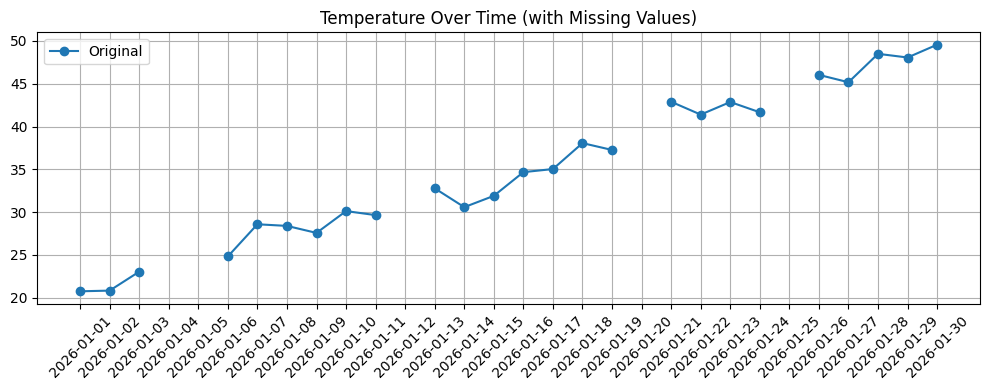

In [9]:
# 2) Plot before interpolation

plt.figure(figsize=(10, 4))
x = df['date']
y = df['temperature']
plt.plot(x, y,  marker='o',  label='Original')

plt.title('Temperature Over Time (with Missing Values)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


         date  temperature  Temp_Interpolated
0  2026-01-01        20.75          20.750000
1  2026-01-02        20.83          20.830000
2  2026-01-03        23.04          23.040000
3  2026-01-04          NaN          23.633333
4  2026-01-05          NaN          24.226667
5  2026-01-06        24.82          24.820000
6  2026-01-07        28.58          28.580000
7  2026-01-08        28.39          28.390000
8  2026-01-09        27.57          27.570000
9  2026-01-10        30.12          30.120000


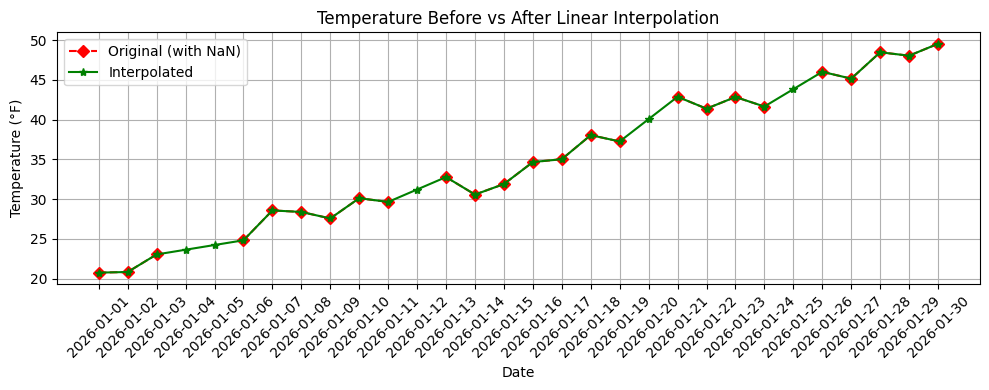

In [15]:
# 3) Interpolate the missing values
df['Temp_Interpolated'] = df['temperature'].interpolate(method='linear')
print(df.head(10))

# Step 4: Plot after interpolation
plt.figure(figsize=(10, 4))

# Original (with NaN)
plt.plot(df['date'], df['temperature'], linestyle='--', marker='D', label='Original (with NaN)', color='red')

# Interpolated
plt.plot(df['date'], df['Temp_Interpolated'], linestyle='-', marker='*', label='Interpolated', color='green')

plt.title('Temperature Before vs After Linear Interpolation')
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### observation
Interpolation works well here because temperature is continuous and changes smoothly over time.